
# Supply Chain Demand Analytics & Inventory Optimization

## Project Overview
This notebook analyzes historical supply-chain demand and inventory data to:

- Explore demand patterns and seasonality
- Measure inventory performance
- Forecast future demand
- Calculate safety stock and reorder points
- Identify overstock and stockout risks
- Optimize inventory targets using service-level assumptions
- Provide actionable supply-chain recommendations

> **Note:** If no external dataset is supplied, the notebook generates a realistic synthetic dataset so that every section can be executed immediately. Replace the synthetic-data section with your own CSV when available.



## 1. Business Problem

Inventory teams must balance two competing risks:

- **Stockouts:** insufficient inventory causes lost sales and poor service levels.
- **Overstock:** excessive inventory increases holding costs and ties up working capital.

The objective is to use historical demand, lead time, inventory, and cost information to estimate appropriate inventory levels while maintaining a target service level.


In [1]:

# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import ceil
from statistics import NormalDist

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Configuration

In [2]:

# Change these settings for a real business dataset
DATA_PATH = None  # Example: "supply_chain_data.csv"

TARGET_SERVICE_LEVEL = 0.95
HOLDING_COST_PER_UNIT = 2.00
ORDERING_COST_PER_ORDER = 100.00
REVIEW_PERIOD_DAYS = 7
FORECAST_HORIZON_DAYS = 30

print("Target service level:", TARGET_SERVICE_LEVEL)
print("Review period:", REVIEW_PERIOD_DAYS, "days")
print("Forecast horizon:", FORECAST_HORIZON_DAYS, "days")


Target service level: 0.95
Review period: 7 days
Forecast horizon: 30 days


## 3. Load or Generate Data

In [3]:

def generate_supply_chain_data(n_days=730, n_products=8, seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2024-01-01", periods=n_days, freq="D")

    products = [f"SKU-{i:03d}" for i in range(1, n_products + 1)]
    categories = {
        p: ["Electronics", "Home", "Office", "Personal Care"][i % 4]
        for i, p in enumerate(products)
    }

    rows = []
    for i, product in enumerate(products):
        base = 25 + i * 7
        trend_strength = 0.015 + i * 0.002
        seasonality = 0.18 + (i % 3) * 0.04
        lead_time = 4 + (i % 5)
        unit_cost = 12 + i * 4

        for day_idx, date in enumerate(dates):
            weekly = 1 + 0.12 * np.sin(2 * np.pi * date.dayofweek / 7)
            yearly = 1 + seasonality * np.sin(
                2 * np.pi * date.dayofyear / 365.25
            )
            trend = 1 + trend_strength * day_idx / 30
            noise = rng.normal(1.0, 0.12)

            demand = max(0, base * weekly * yearly * trend * noise)
            demand = int(round(demand))

            on_hand = max(
                0,
                int(round(base * 2.2 + rng.normal(0, base * 0.45)))
            )

            orders = int(demand * rng.uniform(0.85, 1.10))
            rows.append([
                date, product, categories[product], demand,
                on_hand, lead_time, unit_cost, orders
            ])

    return pd.DataFrame(rows, columns=[
        "date", "product_id", "category", "demand",
        "inventory", "lead_time_days", "unit_cost", "orders"
    ])

if DATA_PATH:
    df = pd.read_csv(DATA_PATH)
    df["date"] = pd.to_datetime(df["date"])
    print(f"Loaded dataset from: {DATA_PATH}")
else:
    df = generate_supply_chain_data()
    print("No external dataset supplied; generated synthetic supply-chain data.")

df.head()


No external dataset supplied; generated synthetic supply-chain data.


,date,product_id,category,demand,inventory,lead_time_days,unit_cost,orders
0,2024-01-01,SKU-001,Electronics,26,43,4,12,27
1,2024-01-02,SKU-001,Electronics,31,33,4,12,33
2,2024-01-03,SKU-001,Electronics,29,51,4,12,25
3,2024-01-04,SKU-001,Electronics,24,65,4,12,25
4,2024-01-05,SKU-001,Electronics,24,68,4,12,23



### Expected columns for a real dataset

At minimum, the analysis expects:

`date`, `product_id`, `demand`, `inventory`, `lead_time_days`, and `unit_cost`.

Optional columns such as `category` and `orders` improve the analysis.


In [4]:

# Basic validation
required = ["date", "product_id", "demand", "inventory", "lead_time_days", "unit_cost"]
missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.sort_values(["product_id", "date"]).reset_index(drop=True)

print("Rows:", len(df))
print("Products:", df["product_id"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("\nMissing values:")
print(df[required].isna().sum())


Rows: 5840
Products: 8
Date range: 2024-01-01 to 2025-12-30

Missing values:
date              0
product_id        0
demand            0
inventory         0
lead_time_days    0
unit_cost         0
dtype: int64


## 4. Exploratory Demand Analysis

In [5]:

summary = df.groupby("product_id").agg(
    total_demand=("demand", "sum"),
    avg_daily_demand=("demand", "mean"),
    demand_std=("demand", "std"),
    avg_inventory=("inventory", "mean"),
    avg_lead_time=("lead_time_days", "mean"),
    unit_cost=("unit_cost", "mean")
).sort_values("total_demand", ascending=False)

summary


,total_demand,avg_daily_demand,demand_std,avg_inventory,avg_lead_time,unit_cost
product_id,,,,,,
SKU-008,71993,98.62,22.48,164.08,6.00,40.00
SKU-007,64693,88.62,18.69,149.14,5.00,36.00
SKU-006,56254,77.06,17.57,130.35,4.00,32.00
SKU-005,49118,67.28,14.68,114.85,8.00,28.00
SKU-004,42072,57.63,11.42,100.78,7.00,24.00
SKU-003,35000,47.95,11.32,85.48,6.00,20.00
SKU-002,28071,38.45,8.33,70.86,5.00,16.00
SKU-001,21304,29.18,5.62,54.42,4.00,12.00


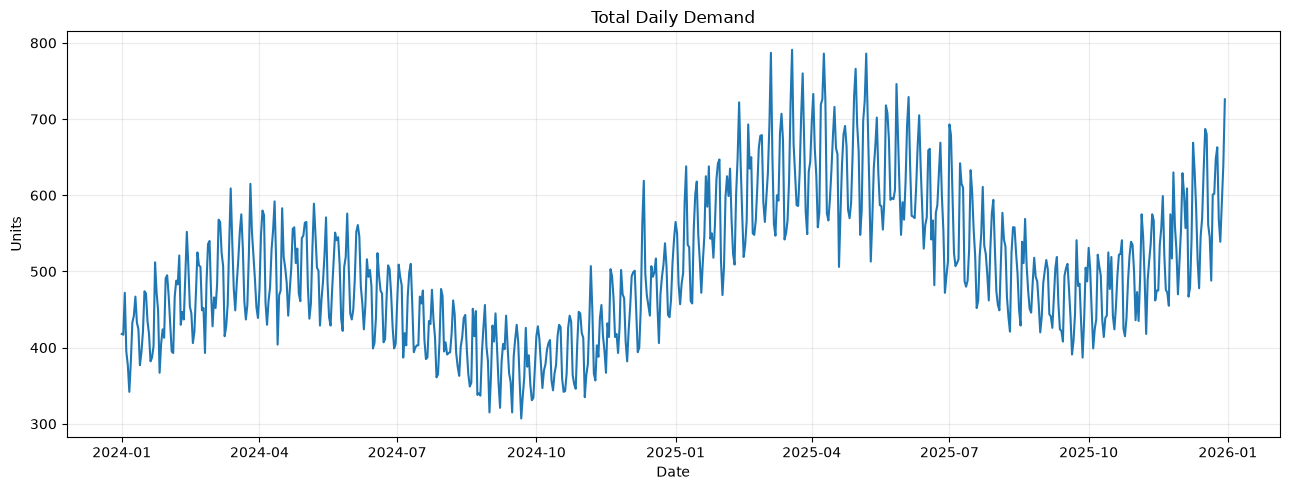

In [6]:

# Total demand over time
daily_total = df.groupby("date")["demand"].sum()

plt.figure(figsize=(13, 5))
plt.plot(daily_total.index, daily_total.values)
plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


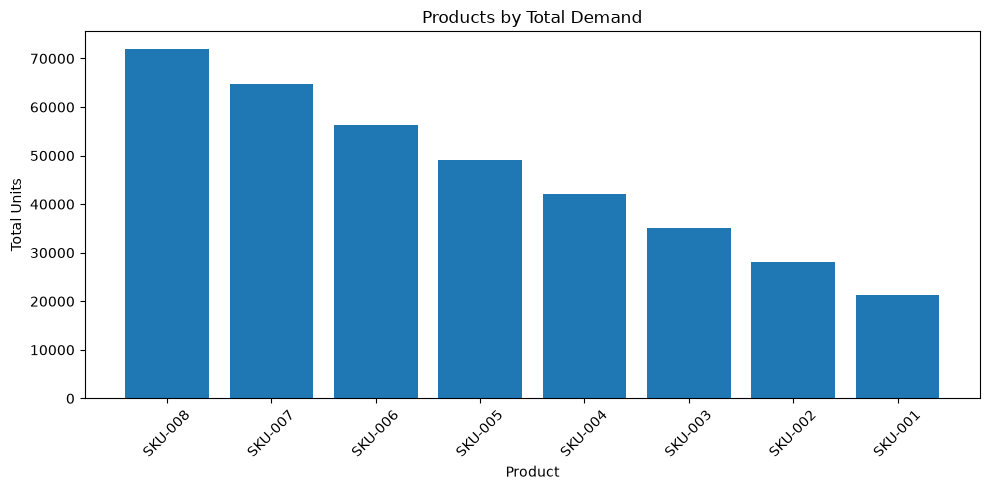

In [7]:

# Top products by total demand
top_products = (
    df.groupby("product_id")["demand"]
      .sum()
      .sort_values(ascending=False)
      .head(8)
)

plt.figure(figsize=(10, 5))
plt.bar(top_products.index, top_products.values)
plt.title("Products by Total Demand")
plt.xlabel("Product")
plt.ylabel("Total Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


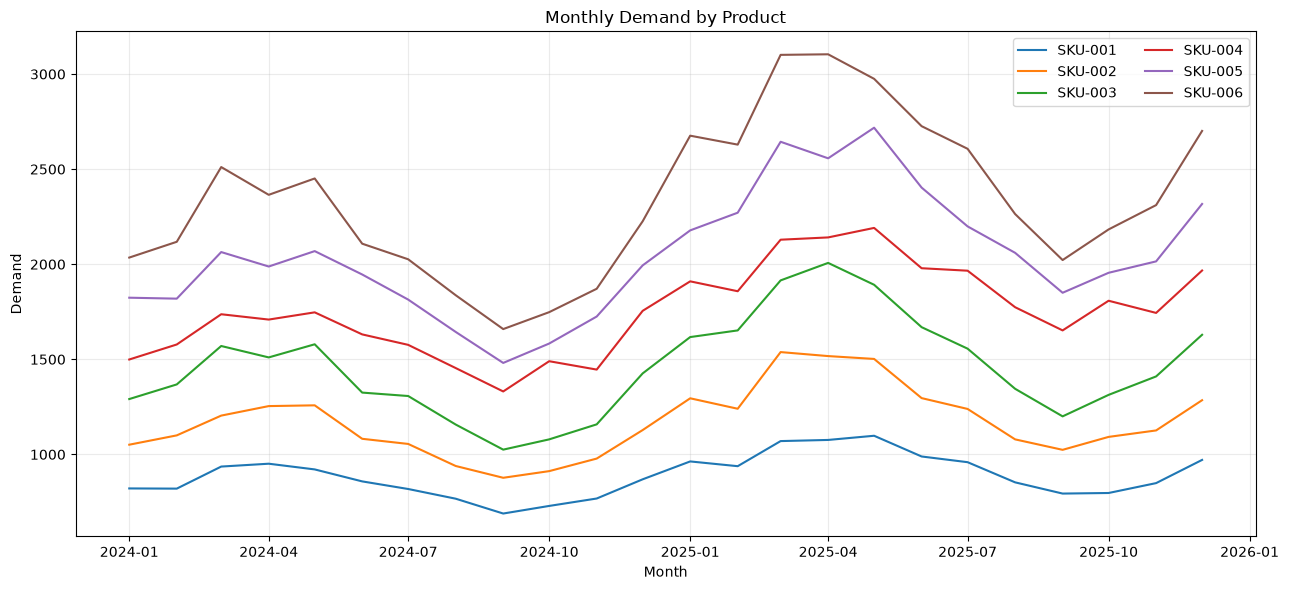

In [8]:

# Monthly demand and seasonality
monthly = (
    df.set_index("date")
      .groupby("product_id")["demand"]
      .resample("MS")
      .sum()
      .reset_index()
)

plt.figure(figsize=(13, 6))
for product in monthly["product_id"].unique()[:6]:
    subset = monthly[monthly["product_id"] == product]
    plt.plot(subset["date"], subset["demand"], label=product)

plt.title("Monthly Demand by Product")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 5. Inventory Performance Metrics

In [9]:

# Inventory turnover and days of inventory
inventory_metrics = df.groupby("product_id").agg(
    annualized_demand=("demand", lambda x: x.mean() * 365),
    average_inventory=("inventory", "mean"),
    unit_cost=("unit_cost", "mean"),
    total_demand=("demand", "sum")
).reset_index()

inventory_metrics["annual_demand_value"] = (
    inventory_metrics["annualized_demand"] *
    inventory_metrics["unit_cost"]
)

inventory_metrics["average_inventory_value"] = (
    inventory_metrics["average_inventory"] *
    inventory_metrics["unit_cost"]
)

inventory_metrics["inventory_turnover"] = (
    inventory_metrics["annual_demand_value"] /
    inventory_metrics["average_inventory_value"].replace(0, np.nan)
)

inventory_metrics["days_of_inventory"] = (
    365 / inventory_metrics["inventory_turnover"].replace(0, np.nan)
)

inventory_metrics.sort_values("inventory_turnover", ascending=False)


,product_id,annualized_demand,average_inventory,unit_cost,total_demand,annual_demand_value,average_inventory_value,inventory_turnover,days_of_inventory
7,SKU-008,"35,996.50",164.08,40.00,71993,"1,439,860.00","6,563.07",219.39,1.66
6,SKU-007,"32,346.50",149.14,36.00,64693,"1,164,474.00","5,369.08",216.89,1.68
5,SKU-006,"28,127.00",130.35,32.00,56254,"900,064.00","4,171.13",215.78,1.69
4,SKU-005,"24,559.00",114.85,28.00,49118,"687,652.00","3,215.86",213.83,1.71
3,SKU-004,"21,036.00",100.78,24.00,42072,"504,864.00","2,418.64",208.74,1.75
2,SKU-003,"17,500.00",85.48,20.00,35000,"350,000.00","1,709.70",204.71,1.78
1,SKU-002,"14,035.50",70.86,16.00,28071,"224,568.00","1,133.70",198.08,1.84
0,SKU-001,"10,652.00",54.42,12.00,21304,"127,824.00",653.05,195.73,1.86



## 6. Demand Forecasting

A practical baseline forecast is created using:

1. Recent moving-average demand
2. Recent demand volatility
3. A seasonal-naive comparison where enough history exists

For operational inventory planning, a transparent baseline is often useful before moving to more complex ML models.


In [10]:

def moving_average_forecast(product_df, window=28, horizon=30):
    series = product_df.sort_values("date")["demand"].astype(float)
    recent = series.tail(window)
    forecast_value = recent.mean()
    return np.repeat(forecast_value, horizon)

forecast_rows = []

for product, group in df.groupby("product_id"):
    forecast = moving_average_forecast(group, window=28, horizon=FORECAST_HORIZON_DAYS)
    for i, value in enumerate(forecast, start=1):
        forecast_rows.append([
            product,
            df["date"].max() + pd.Timedelta(days=i),
            value
        ])

forecast_df = pd.DataFrame(
    forecast_rows,
    columns=["product_id", "date", "forecast_demand"]
)

forecast_df.head()


,product_id,date,forecast_demand
0,SKU-001,2025-12-31,32.32
1,SKU-001,2026-01-01,32.32
2,SKU-001,2026-01-02,32.32
3,SKU-001,2026-01-03,32.32
4,SKU-001,2026-01-04,32.32


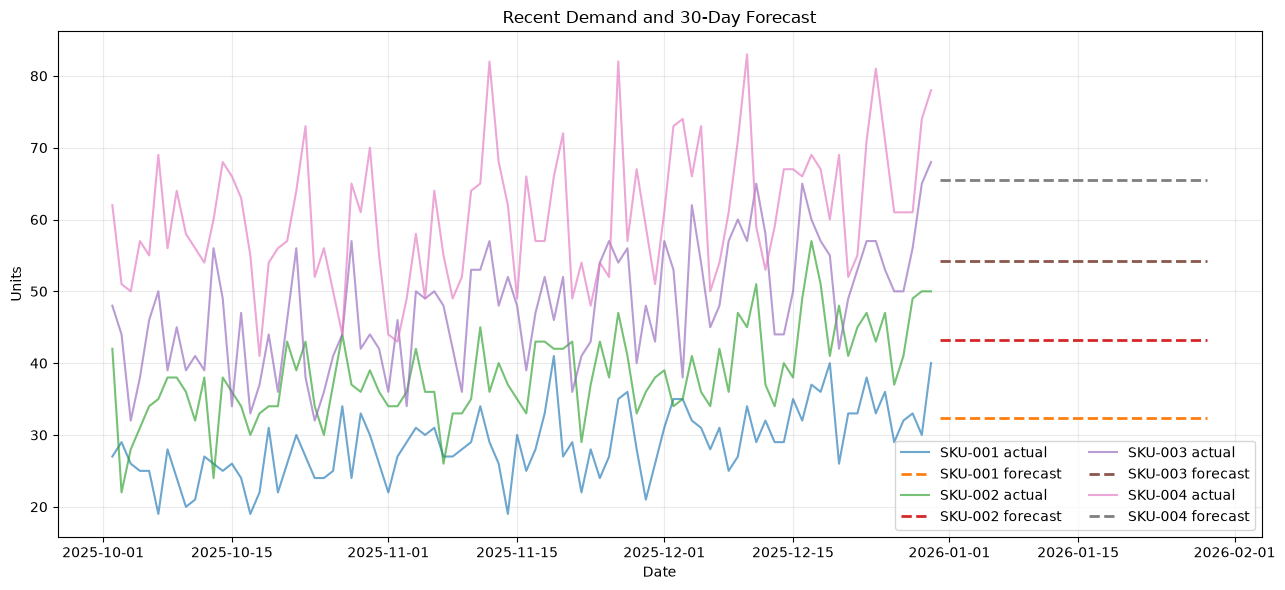

In [11]:

# Forecast visualization for selected products
plt.figure(figsize=(13, 6))

for product in df["product_id"].unique()[:4]:
    history = df[df["product_id"] == product].tail(90)
    future = forecast_df[forecast_df["product_id"] == product]

    plt.plot(history["date"], history["demand"], alpha=0.65, label=f"{product} actual")
    plt.plot(
        future["date"],
        future["forecast_demand"],
        linestyle="--",
        linewidth=2,
        label=f"{product} forecast"
    )

plt.title("Recent Demand and 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 7. Forecast Accuracy Backtest

In [12]:

def moving_average_backtest(group, window=28, test_days=30):
    group = group.sort_values("date")
    if len(group) <= window + test_days:
        return np.nan

    train = group.iloc[:-test_days]
    test = group.iloc[-test_days:]
    prediction = train["demand"].tail(window).mean()

    mae = np.mean(np.abs(test["demand"] - prediction))
    rmse = np.sqrt(np.mean((test["demand"] - prediction) ** 2))

    return pd.Series({"MAE": mae, "RMSE": rmse})

backtest = (
    df.groupby("product_id")
      .apply(moving_average_backtest, include_groups=False)
      .reset_index()
)

backtest


,product_id,MAE,RMSE
0,SKU-001,4.35,5.33
1,SKU-002,6.33,7.92
2,SKU-003,8.48,9.96
3,SKU-004,8.54,10.56
4,SKU-005,12.45,16.22
5,SKU-006,14.01,17.36
6,SKU-007,18.24,21.62
7,SKU-008,18.79,22.42


## 8. Safety Stock and Reorder Point

In [13]:

# Z-score for common service levels
z = NormalDist().inv_cdf(TARGET_SERVICE_LEVEL)

planning = []

for product, group in df.groupby("product_id"):
    group = group.sort_values("date")

    recent = group.tail(90)
    avg_daily = recent["demand"].mean()
    demand_std = recent["demand"].std(ddof=1)
    lead_time = recent["lead_time_days"].mean()
    unit_cost = recent["unit_cost"].mean()

    # Safety stock using demand variability over lead time
    safety_stock = z * demand_std * np.sqrt(lead_time)
    reorder_point = avg_daily * lead_time + safety_stock

    # Target stock for a periodic-review system
    protection_days = lead_time + REVIEW_PERIOD_DAYS
    target_stock = avg_daily * protection_days + z * demand_std * np.sqrt(protection_days)

    planning.append([
        product, avg_daily, demand_std, lead_time, unit_cost,
        safety_stock, reorder_point, target_stock
    ])

planning_df = pd.DataFrame(planning, columns=[
    "product_id", "avg_daily_demand", "demand_std", "lead_time_days",
    "unit_cost", "safety_stock", "reorder_point", "target_stock"
])

planning_df


,product_id,avg_daily_demand,demand_std,lead_time_days,unit_cost,safety_stock,reorder_point,target_stock
0,SKU-001,28.77,4.88,4.00,12.00,16.05,131.12,343.05
1,SKU-002,38.51,6.26,5.00,16.00,23.01,215.57,497.79
2,SKU-003,47.93,8.43,6.00,20.00,33.96,321.56,673.12
3,SKU-004,60.59,9.32,7.00,24.00,40.54,464.66,905.58
4,SKU-005,69.09,12.34,8.00,28.00,57.42,610.13,"1,114.95"
5,SKU-006,79.18,13.96,4.00,32.00,45.92,362.63,947.11
6,SKU-007,96.60,17.17,5.00,36.00,63.16,546.16,"1,257.05"
7,SKU-008,103.98,18.91,6.00,40.00,76.19,700.06,"1,463.87"



### Formulae

**Safety stock**

$$SS = z \times \sigma_d \times \sqrt{L}$$

**Reorder point**

$$ROP = \bar{d} \times L + SS$$

Where:

- $z$ = service-level z-score
- $\sigma_d$ = daily demand standard deviation
- $L$ = lead time in days
- $\bar{d}$ = average daily demand


## 9. Inventory Gap Analysis

In [14]:

current_inventory = (
    df.sort_values("date")
      .groupby("product_id")
      .tail(1)[["product_id", "inventory"]]
)

optimization = planning_df.merge(current_inventory, on="product_id", how="left")

optimization["inventory_gap"] = (
    optimization["target_stock"] - optimization["inventory"]
)

optimization["recommended_order_qty"] = (
    optimization["inventory_gap"].clip(lower=0).apply(np.ceil)
)

optimization["stockout_risk"] = np.where(
    optimization["inventory"] < optimization["reorder_point"],
    "Reorder / At Risk",
    "Within Target"
)

optimization["excess_inventory"] = (
    optimization["inventory"] - optimization["target_stock"]
).clip(lower=0)

optimization["excess_inventory_value"] = (
    optimization["excess_inventory"] * optimization["unit_cost"]
)

optimization.sort_values("inventory_gap", ascending=False)


,product_id,avg_daily_demand,demand_std,lead_time_days,unit_cost,safety_stock,reorder_point,target_stock,inventory,inventory_gap,recommended_order_qty,stockout_risk,excess_inventory,excess_inventory_value
7,SKU-008,103.98,18.91,6.00,40.00,76.19,700.06,"1,463.87",120,"1,343.87","1,344.00",Reorder / At Risk,0.00,0.00
6,SKU-007,96.60,17.17,5.00,36.00,63.16,546.16,"1,257.05",126,"1,131.05","1,132.00",Reorder / At Risk,0.00,0.00
4,SKU-005,69.09,12.34,8.00,28.00,57.42,610.13,"1,114.95",89,"1,025.95","1,026.00",Reorder / At Risk,0.00,0.00
5,SKU-006,79.18,13.96,4.00,32.00,45.92,362.63,947.11,121,826.11,827.00,Reorder / At Risk,0.00,0.00
3,SKU-004,60.59,9.32,7.00,24.00,40.54,464.66,905.58,104,801.58,802.00,Reorder / At Risk,0.00,0.00
2,SKU-003,47.93,8.43,6.00,20.00,33.96,321.56,673.12,89,584.12,585.00,Reorder / At Risk,0.00,0.00
1,SKU-002,38.51,6.26,5.00,16.00,23.01,215.57,497.79,64,433.79,434.00,Reorder / At Risk,0.00,0.00
0,SKU-001,28.77,4.88,4.00,12.00,16.05,131.12,343.05,69,274.05,275.00,Reorder / At Risk,0.00,0.00


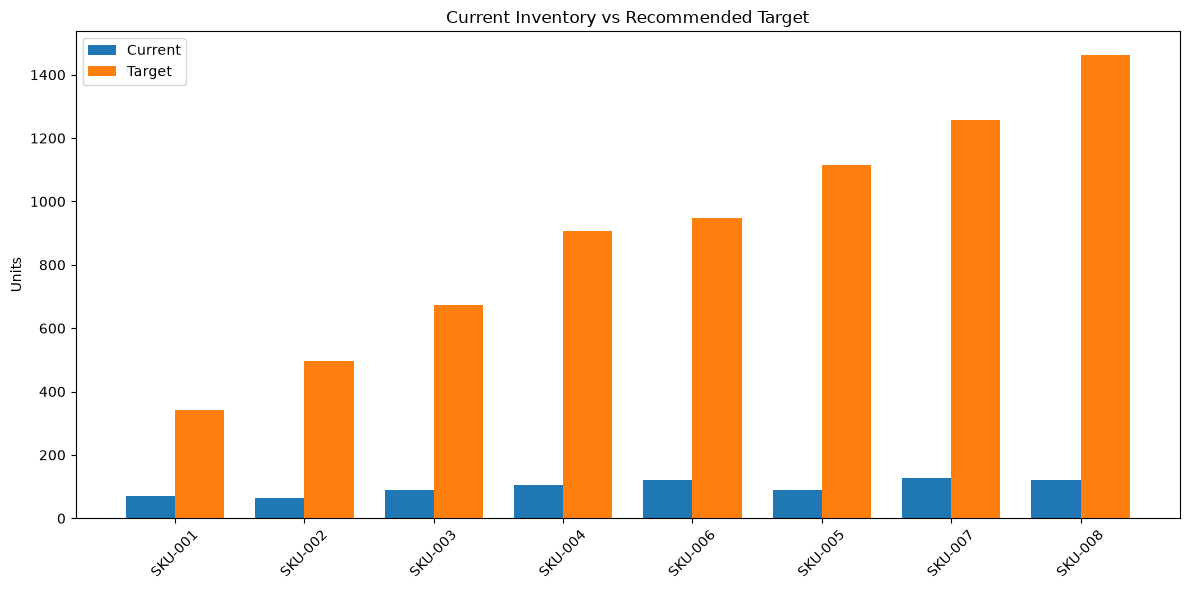

In [15]:

# Current inventory versus target inventory
plot_df = optimization.sort_values("inventory_gap")

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_df["inventory"], width, label="Current")
plt.bar(x + width/2, plot_df["target_stock"], width, label="Target")

plt.xticks(x, plot_df["product_id"], rotation=45)
plt.ylabel("Units")
plt.title("Current Inventory vs Recommended Target")
plt.legend()
plt.tight_layout()
plt.show()


## 10. ABC Inventory Classification

In [16]:

abc = (
    df.groupby("product_id")
      .agg(
          annual_demand=("demand", lambda x: x.mean() * 365),
          unit_cost=("unit_cost", "mean")
      )
      .reset_index()
)

abc["annual_consumption_value"] = (
    abc["annual_demand"] * abc["unit_cost"]
)

abc = abc.sort_values(
    "annual_consumption_value", ascending=False
).reset_index(drop=True)

abc["cumulative_value_pct"] = (
    abc["annual_consumption_value"].cumsum()
    / abc["annual_consumption_value"].sum()
)

abc["ABC_class"] = pd.cut(
    abc["cumulative_value_pct"],
    bins=[0, 0.80, 0.95, 1.00],
    labels=["A", "B", "C"],
    include_lowest=True
)

abc


,product_id,annual_demand,unit_cost,annual_consumption_value,cumulative_value_pct,ABC_class
0,SKU-008,"35,996.50",40.00,"1,439,860.00",0.27,A
1,SKU-007,"32,346.50",36.00,"1,164,474.00",0.48,A
2,SKU-006,"28,127.00",32.00,"900,064.00",0.65,A
3,SKU-005,"24,559.00",28.00,"687,652.00",0.78,A
4,SKU-004,"21,036.00",24.00,"504,864.00",0.87,B
5,SKU-003,"17,500.00",20.00,"350,000.00",0.93,B
6,SKU-002,"14,035.50",16.00,"224,568.00",0.98,C
7,SKU-001,"10,652.00",12.00,"127,824.00",1.00,C



## 11. EOQ Estimation

The Economic Order Quantity provides a basic ordering-size estimate:

$$EOQ = \sqrt{\frac{2DS}{H}}$$

Where:

- $D$ = annual demand
- $S$ = ordering cost per order
- $H$ = annual holding cost per unit


In [17]:

eoq_df = abc.copy()

eoq_df["holding_cost_per_unit_year"] = HOLDING_COST_PER_UNIT

eoq_df["EOQ"] = np.sqrt(
    (2 * eoq_df["annual_demand"] * ORDERING_COST_PER_ORDER)
    / eoq_df["holding_cost_per_unit_year"]
)

eoq_df["EOQ"] = eoq_df["EOQ"].apply(np.ceil).astype(int)

eoq_df[[
    "product_id", "annual_demand", "unit_cost",
    "ABC_class", "EOQ"
]]


,product_id,annual_demand,unit_cost,ABC_class,EOQ
0,SKU-008,"35,996.50",40.00,A,1898
1,SKU-007,"32,346.50",36.00,A,1799
2,SKU-006,"28,127.00",32.00,A,1678
3,SKU-005,"24,559.00",28.00,A,1568
4,SKU-004,"21,036.00",24.00,B,1451
5,SKU-003,"17,500.00",20.00,B,1323
6,SKU-002,"14,035.50",16.00,C,1185
7,SKU-001,"10,652.00",12.00,C,1033


## 12. Inventory Cost Scenario Analysis

In [18]:

# Estimate annual holding cost under current and target inventory policies
cost_analysis = optimization.copy()

cost_analysis["current_holding_cost"] = (
    cost_analysis["inventory"] * cost_analysis["unit_cost"] * 365 / 2
)

cost_analysis["target_holding_cost"] = (
    cost_analysis["target_stock"] * cost_analysis["unit_cost"] * 365 / 2
)

cost_analysis["potential_holding_cost_change"] = (
    cost_analysis["target_holding_cost"]
    - cost_analysis["current_holding_cost"]
)

cost_analysis[[
    "product_id", "inventory", "target_stock",
    "current_holding_cost", "target_holding_cost",
    "potential_holding_cost_change"
]].sort_values("potential_holding_cost_change")


,product_id,inventory,target_stock,current_holding_cost,target_holding_cost,potential_holding_cost_change
0,SKU-001,69,343.05,"151,110.00","751,272.54","600,162.54"
1,SKU-002,64,497.79,"186,880.00","1,453,535.22","1,266,655.22"
2,SKU-003,89,673.12,"324,850.00","2,456,901.42","2,132,051.42"
3,SKU-004,104,905.58,"455,520.00","3,966,433.14","3,510,913.14"
5,SKU-006,121,947.11,"706,640.00","5,531,119.74","4,824,479.74"
4,SKU-005,89,"1,114.95","454,790.00","5,697,410.82","5,242,620.82"
6,SKU-007,126,"1,257.05","827,820.00","8,258,828.63","7,431,008.63"
7,SKU-008,120,"1,463.87","876,000.00","10,686,228.84","9,810,228.84"


## 13. Supply-Chain Dashboard

In [19]:

total_inventory_units = optimization["inventory"].sum()
target_inventory_units = optimization["target_stock"].sum()
total_order_qty = optimization["recommended_order_qty"].sum()
at_risk_count = (optimization["stockout_risk"] == "Reorder / At Risk").sum()
excess_value = optimization["excess_inventory_value"].sum()

print("=" * 55)
print("SUPPLY CHAIN INVENTORY DASHBOARD")
print("=" * 55)
print(f"Products analyzed              : {optimization['product_id'].nunique()}")
print(f"Current inventory (units)      : {total_inventory_units:,.0f}")
print(f"Target inventory (units)       : {target_inventory_units:,.0f}")
print(f"Recommended order quantity     : {total_order_qty:,.0f}")
print(f"Products below reorder point   : {at_risk_count}")
print(f"Estimated excess inventory $   : {excess_value:,.2f}")
print(f"Target service level           : {TARGET_SERVICE_LEVEL:.0%}")
print("=" * 55)


SUPPLY CHAIN INVENTORY DASHBOARD
Products analyzed              : 8
Current inventory (units)      : 782
Target inventory (units)       : 7,203
Recommended order quantity     : 6,425
Products below reorder point   : 8
Estimated excess inventory $   : 0.00
Target service level           : 95%


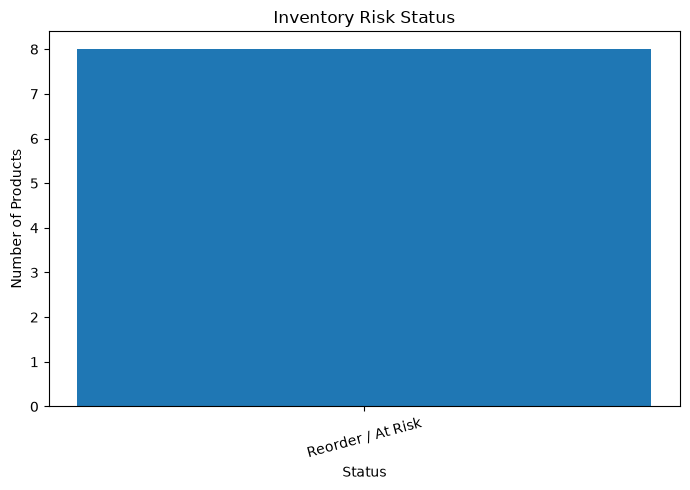

In [20]:

# Risk segmentation
risk_counts = optimization["stockout_risk"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Inventory Risk Status")
plt.xlabel("Status")
plt.ylabel("Number of Products")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



## 14. Recommended Operational Actions

The model can support the following workflow:

1. **Prioritize products below the reorder point.**
2. **Use recommended order quantities as a starting point**, subject to supplier minimums, order multiples, and capacity constraints.
3. **Review A-class products more frequently** because they contribute a larger share of annual consumption value.
4. **Monitor demand volatility and lead-time variability** rather than relying only on average demand.
5. **Recalculate safety stock regularly** as demand and service-level requirements change.
6. **Investigate persistent excess inventory** before reducing replenishment blindly.
7. **Compare forecast error over time** and replace the moving-average baseline with a more advanced model if it consistently underperforms.


## 15. Export Results

In [21]:

# Export the main optimization table for use by planners
OUTPUT_FILE = "inventory_optimization_results.csv"

optimization.to_csv(OUTPUT_FILE, index=False)

print(f"Saved: {OUTPUT_FILE}")


Saved: inventory_optimization_results.csv



## 16. Final Conclusion

This project demonstrates an end-to-end supply-chain analytics workflow:

- Historical demand is explored to identify patterns and variability.
- A transparent moving-average forecast estimates near-term demand.
- Forecast accuracy is evaluated with a simple backtest.
- Safety stock and reorder points are calculated from demand volatility, lead time, and service-level targets.
- Current inventory is compared with recommended inventory targets.
- ABC classification highlights products with different consumption-value importance.
- EOQ provides an additional ordering-size reference.
- The final dashboard summarizes products requiring replenishment and potential excess inventory.

### Business value

A production implementation can connect this workflow to ERP, warehouse-management, procurement, and sales systems to refresh forecasts and inventory recommendations automatically.



## 17. Extensions for a Production Version

Possible next steps include:

- XGBoost/LightGBM demand forecasting
- Prophet or SARIMA forecasting
- Intermittent-demand models such as Croston
- Promotion and price-effect features
- Supplier lead-time distributions
- Multi-echelon inventory optimization
- Service-level optimization by SKU class
- MOQ and order-multiple constraints
- Warehouse capacity constraints
- Supplier reliability scoring
- Automated alerts for stockout and excess-inventory risks
- Streamlit/Power BI dashboard deployment
